# Uticaj predobrade teksta na performanse u analizi sentimenta Amazon recenzija

## Cilj rada

Cilj ovog istraživanja je da se sistematično izmeri **kako svaka tehnika predobrade teksta utiče na performanse modela** u zadatku binarne klasifikacije sentimenta Amazon recenzija.

Eksperiment je organizovan po sledećem principu:
-  **dva modela**: Logistička regresija i SVM
-  **reprezentacija teksta**: TF-IDF (max 5000 feature-a)
- Merimo F1, Accuracy, Precision i Recall za svaku kombinaciju

Na osnovu vrednosti ocene formirana je binarna klasifikacija sentimenta:
- **negativan (0)** — ocene 1 i 2
- **pozitivan (1)** — ocene 4 i 5
- Neutralne ocene (3) su uklonjene

## 1. Instalacija i importi

In [1]:
!pip install gensim wordcloud imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.8 MB/s eta 0:00:00


In [2]:
import random
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

from imblearn.over_sampling import SMOTE

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## 2. Učitavanje i priprema podataka

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/My Drive/Reviews.csv')

# Zadržavamo samo relevantne kolone
df = df[['Text', 'Score']]

# Uzimamo uzorak radi efikasnosti
df = df.sample(10000, random_state=RANDOM_STATE)

# Čišćenje
df = df.drop_duplicates().dropna()

# Formiramo binarni sentiment (uklanjamo neutralne ocene)
df = df[df['Score'] != 3].copy()
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

print("Shape:", df.shape)
print("\nDistribucija sentimenta:")
print(df['Sentiment'].value_counts())
display(df.head())

Shape: (9079, 3)

Distribucija sentimenta:
Sentiment
1    7707
0    1372
Name: count, dtype: int64


,Text,Score,Sentiment
165256,Having tried a couple of other brands of glute...,5,1
231465,My cat loves these treats. If ever I can't fin...,5,1
433954,"First there was Frosted Mini-Wheats, in origin...",2,0
70260,and I want to congratulate the graphic artist ...,5,1
49866,Please add more Pineapple flavor to your packa...,4,1


## 3. Eksplorativna analiza podataka (EDA)

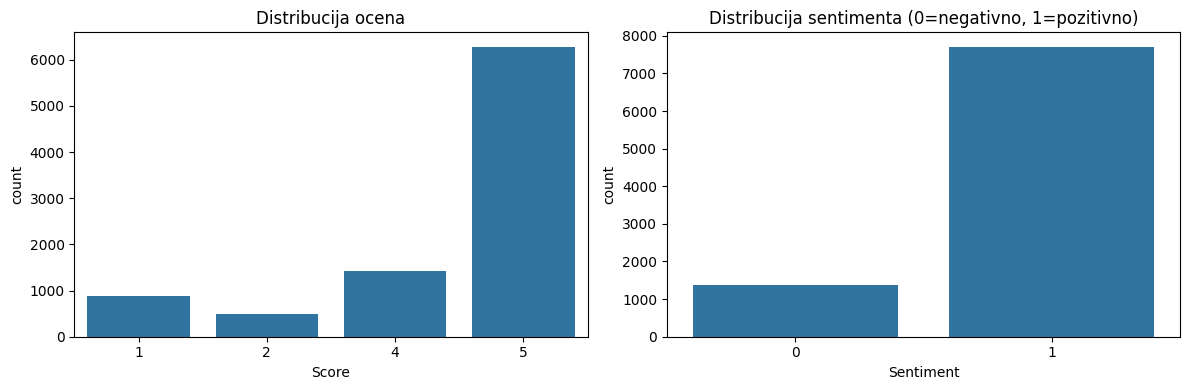

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=df['Score'], ax=axes[0])
axes[0].set_title('Distribucija ocena')

sns.countplot(x=df['Sentiment'], ax=axes[1])
axes[1].set_title('Distribucija sentimenta (0=negativno, 1=pozitivno)')

plt.tight_layout()
plt.show()

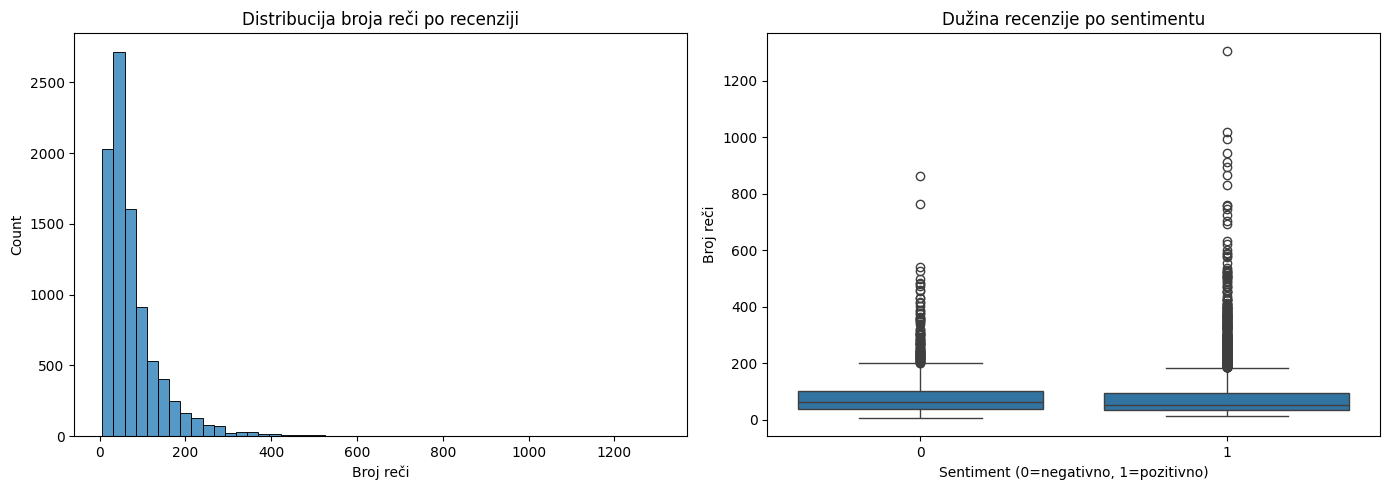

Prosečan broj reči po sentimentu:
Sentiment
0    85.918367
1    77.320099
Name: word_count, dtype: float64


In [6]:
df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['word_count'], bins=50, ax=axes[0])
axes[0].set_title('Distribucija broja reči po recenziji')
axes[0].set_xlabel('Broj reči')

sns.boxplot(x='Sentiment', y='word_count', data=df, ax=axes[1])
axes[1].set_title('Dužina recenzije po sentimentu')
axes[1].set_xlabel('Sentiment (0=negativno, 1=pozitivno)')
axes[1].set_ylabel('Broj reči')

plt.tight_layout()
plt.show()

print("Prosečan broj reči po sentimentu:")
print(df.groupby('Sentiment')['word_count'].mean())

## 4. Definisanje tehnika predobrade

Svaka tehnika predobrade gradi na prethodnoj — formiramo **pipeline**:

| Korak | Naziv | Opis |
|-------|-------|------|
| 1 | Raw Text | Originalni tekst bez izmena |
| 2 | Lowercase + HTML/Spec.chars | Normalizacija, uklanjanje HTML i specijalnih znakova |
| 3 | + Tokenizacija + Stop words | Tokenizacija i uklanjanje stop reči |
| 4 | + Stemovanje | Dodatno stemovanje tokena |
| 5 | + Lematizacija | Umesto stemovanja — lematizacija (poseban pipeline) |
| 6 | + Synonym Replacement | Augmentacija zamenom sinonima |
| 7 | + Random Deletion | Augmentacija slučajnim brisanjem reči |
| 8 | + Random Swap | Augmentacija zamenom pozicija reči |

In [7]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


#  Korak 1: Sirovi tekst
df['v1_raw'] = df['Text'].astype(str)


# Korak 2: Lowercase + uklanjanje HTML i specijalnih karaktera
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)          # ukloni HTML tagove
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # ukloni ne-slova
    text = re.sub(r'\s+', ' ', text).strip()
    text = unicodedata.normalize('NFKD', text)
    return text

df['v2_clean'] = df['v1_raw'].apply(normalize_text)


#  Korak 3: Tokenizacija + uklanjanje stop reči
def tokenize_remove_stopwords(text):
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and w.isalpha()]
    return ' '.join(tokens)

df['v3_tokenized'] = df['v2_clean'].apply(tokenize_remove_stopwords)


#  Korak 4: Stemovanje
def apply_stemming(text):
    tokens = text.split()
    return ' '.join([stemmer.stem(w) for w in tokens])

df['v4_stemmed'] = df['v3_tokenized'].apply(apply_stemming)


#  Korak 5: Lematizacija (alternativa stemovanju)
def apply_lemmatization(text):
    tokens = text.split()
    return ' '.join([lemmatizer.lemmatize(w) for w in tokens])

df['v5_lemmatized'] = df['v3_tokenized'].apply(apply_lemmatization)


#  Korak 6: Augmentacija — Synonym Replacement
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonyms.add(lemma.name().replace('_', ' '))
    synonyms.discard(word)
    return list(synonyms)

def synonym_replacement(text, n=1):
    tokens = text.split()
    new_tokens = tokens.copy()
    candidates = list(set(tokens))
    random.shuffle(candidates)
    replaced = 0
    for word in candidates:
        syns = get_synonyms(word)
        if syns:
            syn = random.choice(syns)
            new_tokens = [syn if w == word else w for w in new_tokens]
            replaced += 1
        if replaced >= n:
            break
    return ' '.join(new_tokens)

df['v6_synonym'] = df['v5_lemmatized'].apply(lambda x: synonym_replacement(x, n=1))


# Korak 7: Random Deletion
def random_deletion(text, p=0.1):
    tokens = text.split()
    if len(tokens) <= 1:
        return text
    new_tokens = [w for w in tokens if random.uniform(0, 1) > p]
    return ' '.join(new_tokens) if new_tokens else random.choice(tokens)

df['v7_deletion'] = df['v6_synonym'].apply(lambda x: random_deletion(x, p=0.1))


#  Korak 8: Random Swap
def random_swap(text, n=1):
    tokens = text.split()
    for _ in range(n):
        if len(tokens) < 2:
            break
        i, j = random.sample(range(len(tokens)), 2)
        tokens[i], tokens[j] = tokens[j], tokens[i]
    return ' '.join(tokens)

df['v8_swap'] = df['v7_deletion'].apply(lambda x: random_swap(x, n=1))


print('\nPrimeri transformacije jednog teksta:')
idx = df.index[0]
for version in ['v1_raw', 'v2_clean', 'v3_tokenized', 'v4_stemmed', 'v5_lemmatized',
                'v6_synonym', 'v7_deletion', 'v8_swap']:
    print(f"\n[{version}]\n  {df.loc[idx, version][:120]}...")

✓ Sve tehnike predobrade primenjene.

Primeri transformacije jednog teksta:

[v1_raw]
  Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy...

[v2_clean]
  having tried a couple of other brands of glutenfree sandwich cookies these are the best of the bunch theyre crunchy and ...

[v3_tokenized]
  tried couple brands glutenfree sandwich cookies best bunch theyre crunchy true texture real cookies arent glutenfree mig...

[v4_stemmed]
  tri coupl brand glutenfre sandwich cooki best bunch theyr crunchi true textur real cooki arent glutenfre might think fil...

[v5_lemmatized]
  tried couple brand glutenfree sandwich cooky best bunch theyre crunchy true texture real cooky arent glutenfree might th...

[v6_synonym]
  tried couple brand glutenfree sandwich cooky best bunch theyre crunchy true texture real cooky arent glutenfree might th...

[v7_deletion]
  couple brand sandwich cooky best bunch theyre crunchy true texture r

## 5. Analiza uticaja predobrade

Pre nego što treniramo modele, vidimo kako predobrada smanjuje veličinu rečnika — što je direktan indikator normalizacije teksta.

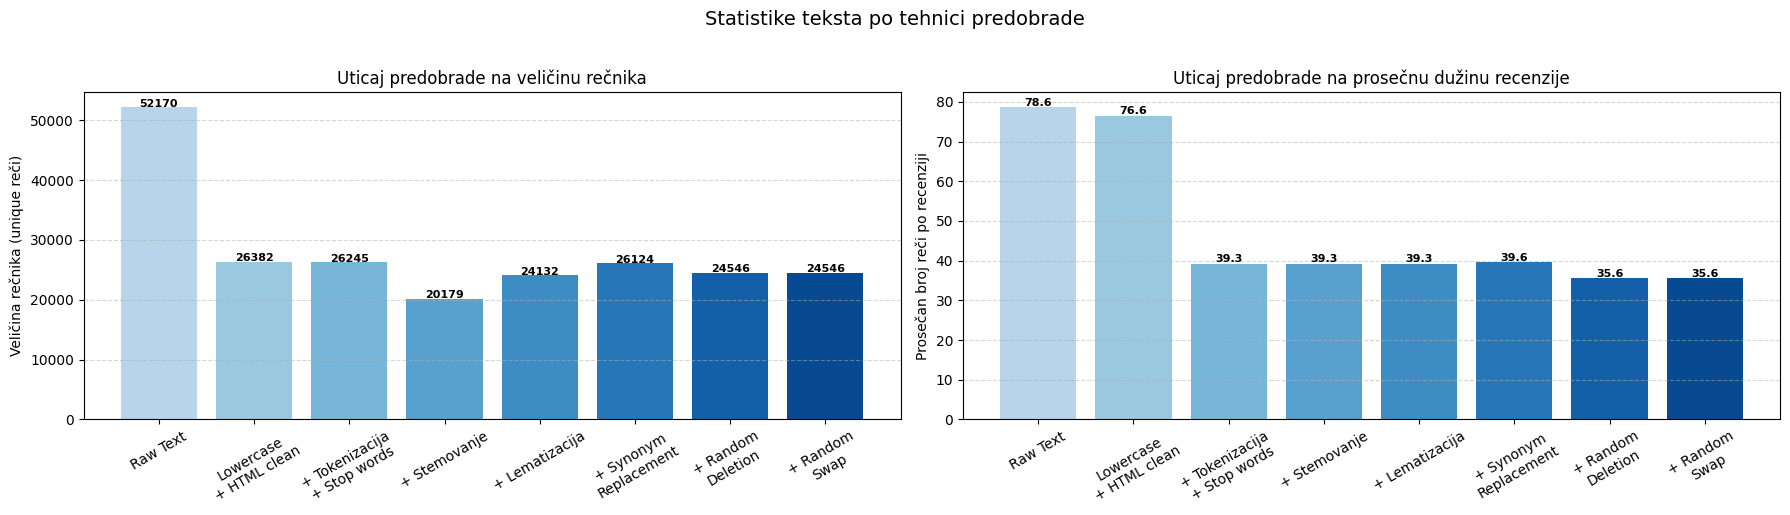


Summary tabela:


,Veličina rečnika,Prosečna dužina
Raw Text,52170,78.619451
Lowercase\n+ HTML clean,26382,76.564600
+ Tokenizacija\n+ Stop words,26245,39.268091
+ Stemovanje,20179,39.268091
+ Lematizacija,24132,39.268091
+ Synonym\nReplacement,26124,39.572971
+ Random\nDeletion,24546,35.577046
+ Random\nSwap,24546,35.577046


In [8]:
versions_meta = {
    'v1_raw':        'Raw Text',
    'v2_clean':      'Lowercase\n+ HTML clean',
    'v3_tokenized':  '+ Tokenizacija\n+ Stop words',
    'v4_stemmed':    '+ Stemovanje',
    'v5_lemmatized': '+ Lematizacija',
    'v6_synonym':    '+ Synonym\nReplacement',
    'v7_deletion':   '+ Random\nDeletion',
    'v8_swap':       '+ Random\nSwap',
}

vocab_sizes = {}
avg_lengths = {}

for col, label in versions_meta.items():
    all_tokens = ' '.join(df[col].astype(str)).split()
    vocab_sizes[label] = len(set(all_tokens))
    avg_lengths[label] = df[col].apply(lambda x: len(str(x).split())).mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(vocab_sizes)))

axes[0].bar(vocab_sizes.keys(), vocab_sizes.values(), color=colors)
axes[0].set_ylabel('Veličina rečnika (unique reči)')
axes[0].set_title('Uticaj predobrade na veličinu rečnika', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
for i, (k, v) in enumerate(vocab_sizes.items()):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=8, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(avg_lengths.keys(), avg_lengths.values(), color=colors)
axes[1].set_ylabel('Prosečan broj reči po recenziji')
axes[1].set_title('Uticaj predobrade na prosečnu dužinu recenzije', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)
for i, (k, v) in enumerate(avg_lengths.items()):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Statistike teksta po tehnici predobrade', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nSummary tabela:")
summary_df = pd.DataFrame({'Veličina rečnika': vocab_sizes, 'Prosečna dužina': avg_lengths})
display(summary_df)

## 6. Trening i evaluacija — Uticaj predobrade

### Metodologija

- **Modeli**: Logistička regresija i SVM — oba modela treniramo na svakoj verziji teksta
- **Reprezentacija**: TF-IDF sa max 5000 feature-a (isti parametri za sve verzije)
- **Balansiranje klasa**: SMOTE na trening skupu
- **Evaluacija**: Accuracy, Precision, Recall, F1 (weighted) na test skupu (20%)


In [9]:
VERSIONS_ORDER = [
    ('v1_raw',        'Raw Text'),
    ('v2_clean',      'Lowercase + HTML clean'),
    ('v3_tokenized',  'Tokenizacija + Stop words'),
    ('v4_stemmed',    'Stemovanje'),
    ('v5_lemmatized', 'Lematizacija'),
    ('v6_synonym',    'Synonym Replacement'),
    ('v7_deletion',   'Random Deletion'),
    ('v8_swap',       'Random Swap'),
]

MODELS = {
    'Logistička regresija': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM':                  LinearSVC(random_state=RANDOM_STATE),
}

def evaluate_preprocessing(text_col, model_name, model):
    """Trenira i evaluira model na datoj koloni teksta, vraća dict metrika."""
    texts = df[text_col].astype(str)
    y     = df['Sentiment']

    X_train, X_test, y_train, y_test = train_test_split(
        texts, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    tfidf = TfidfVectorizer(max_features=5000)
    X_train_v = tfidf.fit_transform(X_train)
    X_test_v  = tfidf.transform(X_test)

    smote = SMOTE(random_state=RANDOM_STATE)
    X_res, y_res = smote.fit_resample(X_train_v.toarray(), y_train)

    model.fit(X_res, y_res)
    y_pred = model.predict(X_test_v)

    return {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1':        f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }


# Treniranje svih kombinacija
results = []

for col, version_name in VERSIONS_ORDER:
    print(f"Obrada: {version_name}...", end=' ')
    for model_name, model in MODELS.items():
        metrics = evaluate_preprocessing(col, model_name, model)
        results.append({
            'Predobrada':  version_name,
            'Model':       model_name,
            **metrics
        })

results_df = pd.DataFrame(results)
print('\n Evaluacija završena.')

Obrada: Raw Text... ✓
Obrada: Lowercase + HTML clean... ✓
Obrada: Tokenizacija + Stop words... ✓
Obrada: Stemovanje... ✓
Obrada: Lematizacija... ✓
Obrada: Synonym Replacement... ✓
Obrada: Random Deletion... ✓
Obrada: Random Swap... ✓

✓ Evaluacija završena.


## 7. Rezultati — Tabelarni prikaz

In [10]:
#  Tabela — Logistička regresija
lr_df = results_df[results_df['Model'] == 'Logistička regresija'].drop(columns='Model').reset_index(drop=True)
svm_df = results_df[results_df['Model'] == 'SVM'].drop(columns='Model').reset_index(drop=True)

print("=" * 65)
print("REZULTATI — Logistička regresija")
print("=" * 65)
display(lr_df.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}'})
    .background_gradient(subset=['F1'], cmap='YlGn')
    .set_caption('Logistička regresija + TF-IDF'))

print("\n" + "=" * 65)
print("REZULTATI — SVM")
print("=" * 65)
display(svm_df.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}'})
    .background_gradient(subset=['F1'], cmap='YlOrRd')
    .set_caption('SVM + TF-IDF'))

REZULTATI — Logistička regresija


,Predobrada,Accuracy,Precision,Recall,F1
0,Raw Text,0.8849,0.8976,0.8849,0.8898
1,Lowercase + HTML clean,0.8789,0.8909,0.8789,0.8836
2,Tokenizacija + Stop words,0.8800,0.8942,0.8800,0.8854
3,Stemovanje,0.8756,0.8943,0.8756,0.8823
4,Lematizacija,0.8794,0.8948,0.8794,0.8852
5,Synonym Replacement,0.8717,0.8896,0.8717,0.8784
6,Random Deletion,0.8623,0.8823,0.8623,0.8698
7,Random Swap,0.8623,0.8823,0.8623,0.8698



REZULTATI — SVM


,Predobrada,Accuracy,Precision,Recall,F1
0,Raw Text,0.8954,0.8990,0.8954,0.8970
1,Lowercase + HTML clean,0.8965,0.9015,0.8965,0.8987
2,Tokenizacija + Stop words,0.8833,0.8908,0.8833,0.8865
3,Stemovanje,0.8816,0.8933,0.8816,0.8862
4,Lematizacija,0.8822,0.8910,0.8822,0.8858
5,Synonym Replacement,0.8756,0.8839,0.8756,0.8791
6,Random Deletion,0.8695,0.8763,0.8695,0.8725
7,Random Swap,0.8695,0.8763,0.8695,0.8725


## 8. Vizualizacija — Uticaj predobrade na F1-score

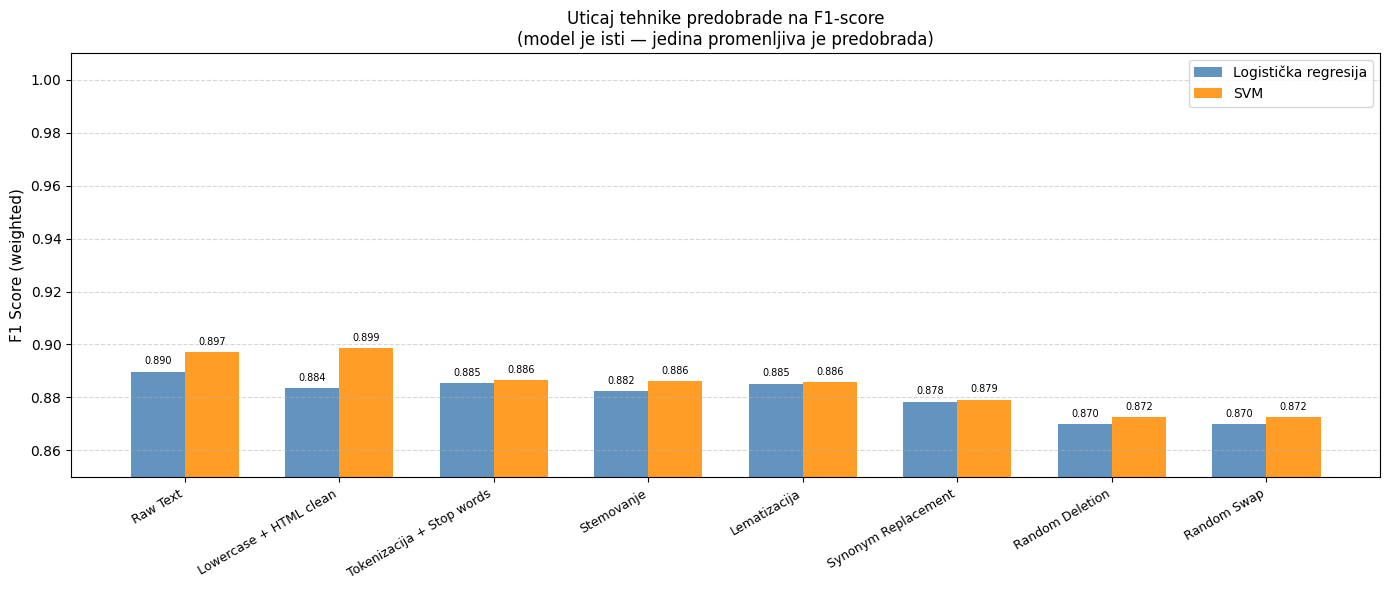

In [11]:
#  Grafikon 1: F1 po tehnici predobrade za oba modela
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(VERSIONS_ORDER))
version_labels = [v[1] for v in VERSIONS_ORDER]
w = 0.35

lr_f1  = [results_df[(results_df['Predobrada'] == v) & (results_df['Model'] == 'Logistička regresija')]['F1'].values[0]
          for _, v in VERSIONS_ORDER]
svm_f1 = [results_df[(results_df['Predobrada'] == v) & (results_df['Model'] == 'SVM')]['F1'].values[0]
          for _, v in VERSIONS_ORDER]

bars1 = ax.bar(x - w/2, lr_f1,  w, label='Logistička regresija', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + w/2, svm_f1, w, label='SVM',                   color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(version_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1 Score (weighted)', fontsize=11)
ax.set_title('Uticaj tehnike predobrade na F1-score', fontsize=12)
ax.set_ylim(min(lr_f1 + svm_f1) - 0.02, 1.01)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

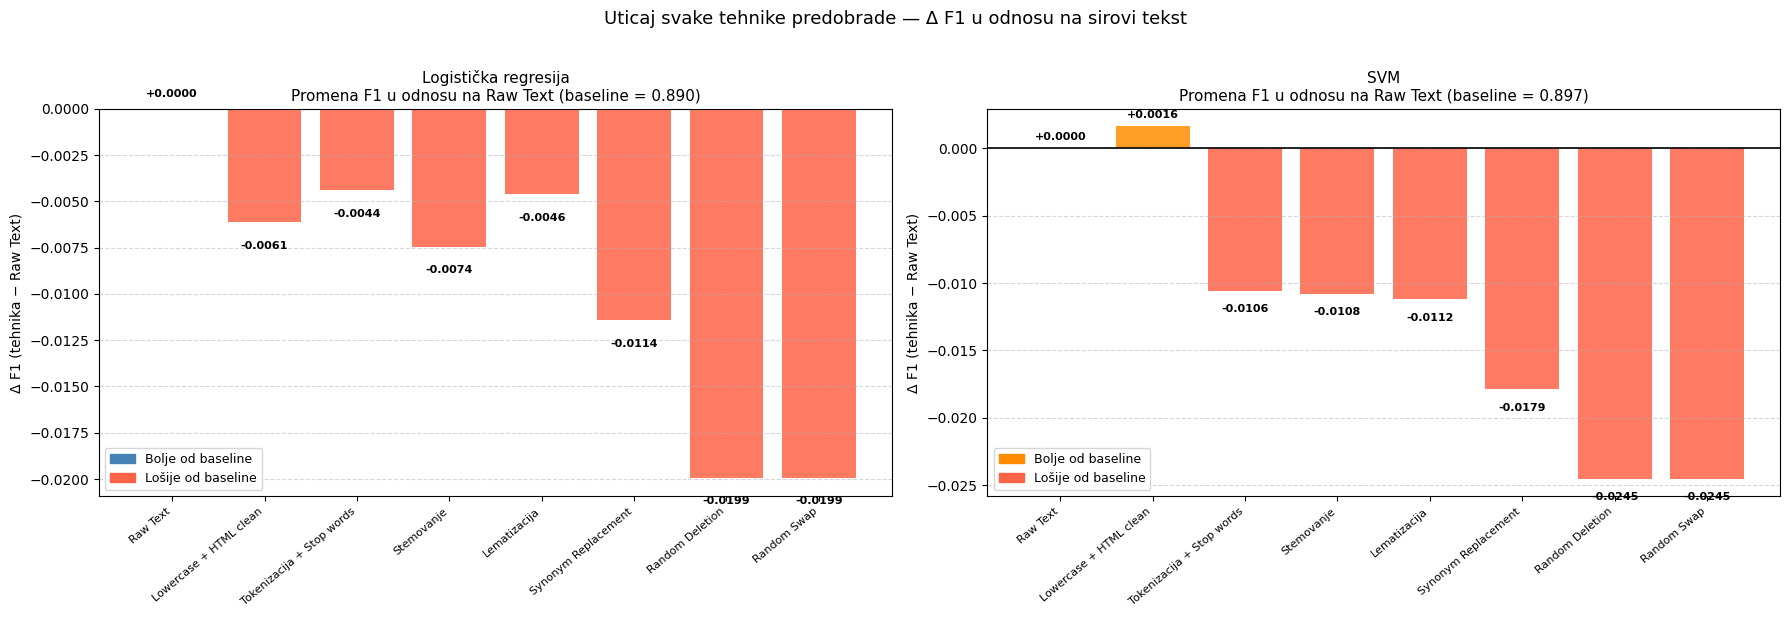

In [12]:
# Grafikon 2: Delta F1 u odnosu na Raw Text baseline
# (Koliko svaka tehnika POBOLJŠAVA ili POGORŠAVA performanse u odnosu na sirovi tekst)

baseline_lr  = lr_f1[0]   # Raw Text + Logistička regresija
baseline_svm = svm_f1[0]  # Raw Text + SVM

delta_lr  = [v - baseline_lr  for v in lr_f1]
delta_svm = [v - baseline_svm for v in svm_f1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, deltas, model_label, base, color in [
    (axes[0], delta_lr,  'Logistička regresija', baseline_lr,  'steelblue'),
    (axes[1], delta_svm, 'SVM',                  baseline_svm, 'darkorange'),
]:
    bar_colors = [color if d >= 0 else 'tomato' for d in deltas]
    bars = ax.bar(range(len(version_labels)), deltas, color=bar_colors, alpha=0.85)
    ax.axhline(0, color='black', linewidth=1.2)
    ax.set_xticks(range(len(version_labels)))
    ax.set_xticklabels(version_labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Δ F1 (tehnika − Raw Text)', fontsize=10)
    ax.set_title(f'{model_label}\nPromena F1 u odnosu na Raw Text (baseline = {base:.3f})', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for i, d in enumerate(deltas):
        ax.text(i, d + (0.0005 if d >= 0 else -0.001), f'{d:+.4f}',
                ha='center', va='bottom' if d >= 0 else 'top', fontsize=8, fontweight='bold')

    pos_patch = mpatches.Patch(color=color, label='Bolje od baseline')
    neg_patch = mpatches.Patch(color='tomato', label='Lošije od baseline')
    ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

plt.suptitle('Uticaj svake tehnike predobrade — Δ F1 u odnosu na sirovi tekst', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

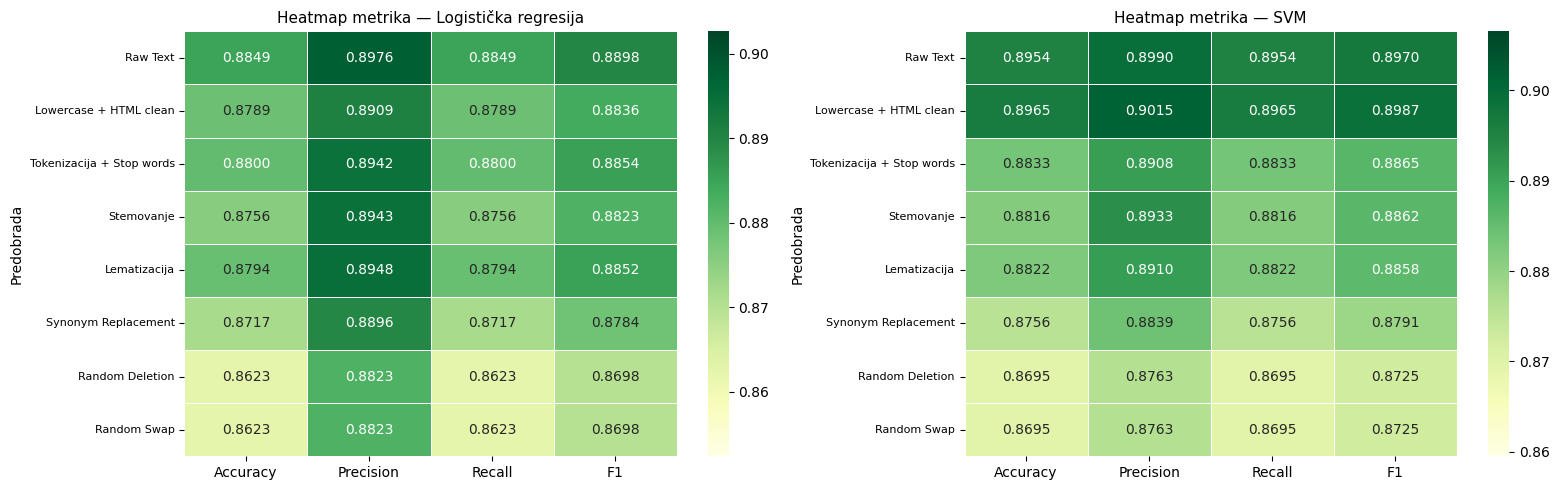

In [13]:
#  Grafikon 3: Heatmap svih metrika
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

for ax, (model_label, model_df) in zip(axes, [
    ('Logistička regresija', lr_df),
    ('SVM', svm_df),
]):
    heatmap_data = model_df.set_index('Predobrada')[metrics]
    sns.heatmap(
        heatmap_data,
        annot=True, fmt='.4f', cmap='YlGn',
        vmin=heatmap_data.values.min() - 0.01,
        vmax=heatmap_data.values.max() + 0.005,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f'Heatmap metrika — {model_label}', fontsize=11)
    ax.set_xlabel('')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

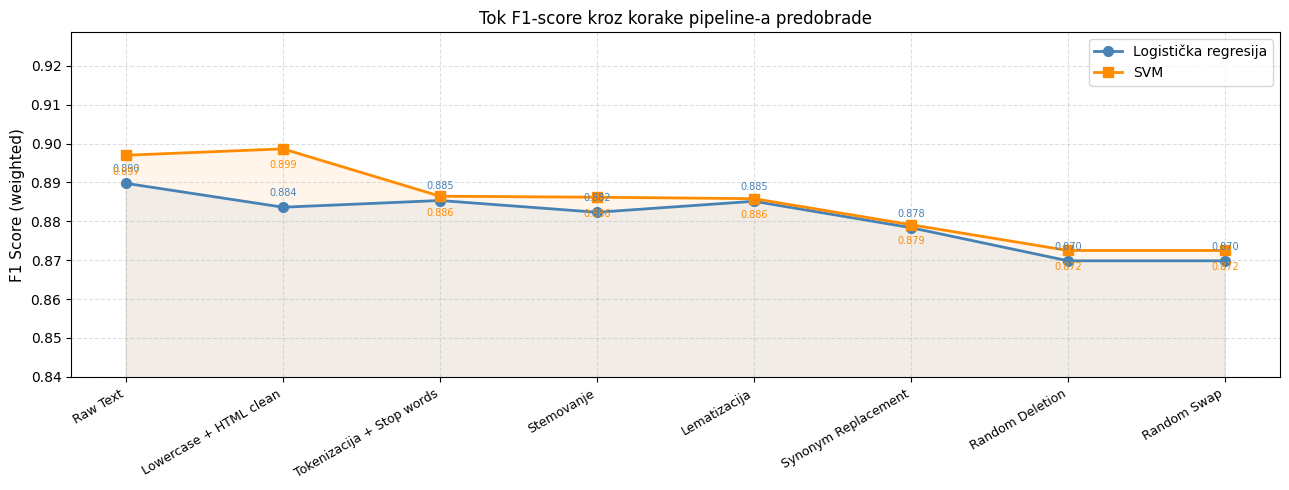

In [14]:
# Grafikon 4: Linijski grafikon — tok F1 kroz pipeline predobrade
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(version_labels, lr_f1,  'o-', color='steelblue',  linewidth=2, markersize=7, label='Logistička regresija')
ax.plot(version_labels, svm_f1, 's-', color='darkorange',  linewidth=2, markersize=7, label='SVM')

ax.fill_between(version_labels, lr_f1,  alpha=0.08, color='steelblue')
ax.fill_between(version_labels, svm_f1, alpha=0.08, color='darkorange')

# Anotiramo svaki korak
for i, (lr, svm) in enumerate(zip(lr_f1, svm_f1)):
    ax.annotate(f'{lr:.3f}', (i, lr), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=7, color='steelblue')
    ax.annotate(f'{svm:.3f}', (i, svm), textcoords='offset points', xytext=(0, -14),
                ha='center', fontsize=7, color='darkorange')

ax.set_xticks(range(len(version_labels)))
ax.set_xticklabels(version_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1 Score (weighted)', fontsize=11)
ax.set_title('Tok F1-score kroz korake pipeline-a predobrade', fontsize=12)
ax.set_ylim(min(lr_f1 + svm_f1) - 0.03, max(lr_f1 + svm_f1) + 0.03)
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 9. Analiza po klasi — Klasifikacioni izveštaj

In [15]:
from sklearn.metrics import classification_report
from sklearn.base import clone

# Prikazujemo classification report za Raw Text vs. Best preprocessing za oba modela
def full_report(text_col, model_name, model):
    texts  = df[text_col].astype(str)
    y      = df['Sentiment']
    X_train, X_test, y_train, y_test = train_test_split(
        texts, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    tfidf   = TfidfVectorizer(max_features=5000)
    X_tr_v  = tfidf.fit_transform(X_train)
    X_te_v  = tfidf.transform(X_test)
    smote   = SMOTE(random_state=RANDOM_STATE)
    X_r, y_r = smote.fit_resample(X_tr_v.toarray(), y_train)
    m = clone(model)
    m.fit(X_r, y_r)
    y_pred  = m.predict(X_te_v)
    print(f"\n{'='*55}")
    print(f"  {model_name}  |  Predobrada: {text_col}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Negativno (0)', 'Pozitivno (1)'],
                                 zero_division=0))

# Pronalazimo best predobradu za svaki model
best_lr_version  = lr_df.loc[lr_df['F1'].idxmax(), 'Predobrada']
best_svm_version = svm_df.loc[svm_df['F1'].idxmax(), 'Predobrada']

best_lr_col  = [c for c, v in VERSIONS_ORDER if v == best_lr_version][0]
best_svm_col = [c for c, v in VERSIONS_ORDER if v == best_svm_version][0]

print(f"Najbolja predobrada za Logističku regresiju: {best_lr_version}")
print(f"Najbolja predobrada za SVM: {best_svm_version}")

full_report('v1_raw',       'Logistička regresija', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
full_report(best_lr_col,    'Logistička regresija', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
full_report('v1_raw',       'SVM',                  LinearSVC(random_state=RANDOM_STATE))
full_report(best_svm_col,   'SVM',                  LinearSVC(random_state=RANDOM_STATE))

Najbolja predobrada za Logističku regresiju: Raw Text
Najbolja predobrada za SVM: Lowercase + HTML clean

  Logistička regresija  |  Predobrada: v1_raw
               precision    recall  f1-score   support

Negativno (0)       0.60      0.74      0.66       274
Pozitivno (1)       0.95      0.91      0.93      1542

     accuracy                           0.88      1816
    macro avg       0.77      0.82      0.79      1816
 weighted avg       0.90      0.88      0.89      1816


  Logistička regresija  |  Predobrada: v1_raw
               precision    recall  f1-score   support

Negativno (0)       0.60      0.74      0.66       274
Pozitivno (1)       0.95      0.91      0.93      1542

     accuracy                           0.88      1816
    macro avg       0.77      0.82      0.79      1816
 weighted avg       0.90      0.88      0.89      1816


  SVM  |  Predobrada: v1_raw
               precision    recall  f1-score   support

Negativno (0)       0.64      0.69      0.67     

## 10. Finalni zaključci

### Sažetak nalaza

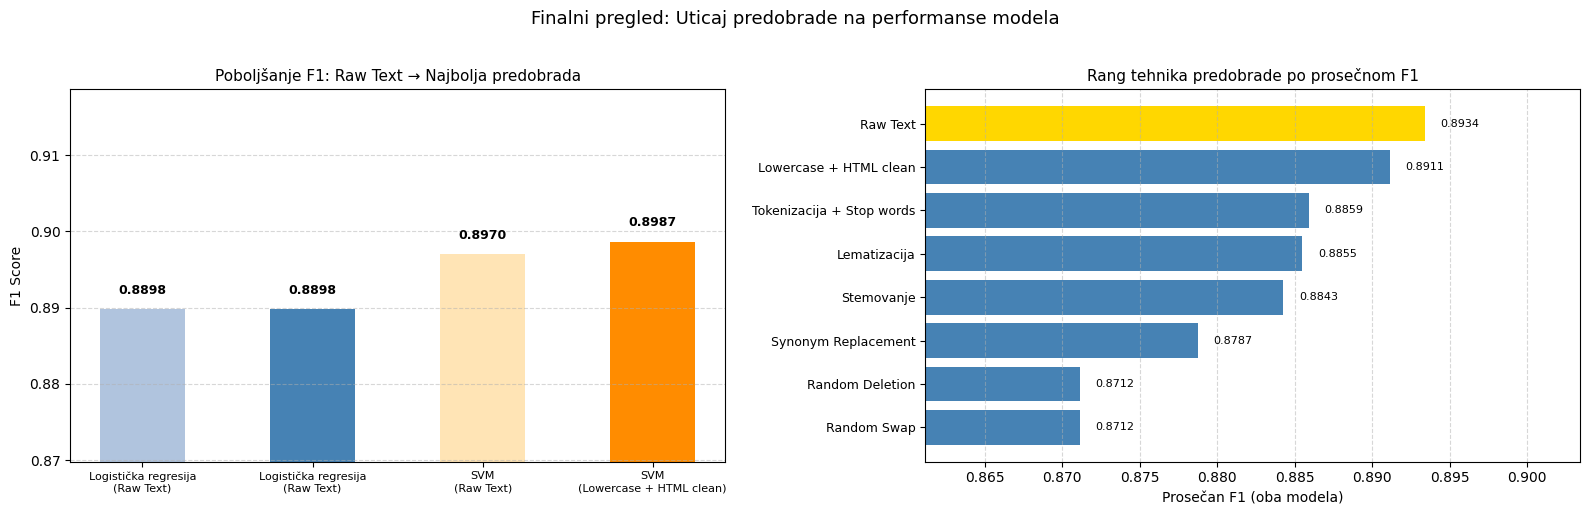

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grafikon 1: Poređenje Raw Text vs. Best predobrade
best_lr_f1  = lr_df['F1'].max()
best_svm_f1 = svm_df['F1'].max()

categories = ['Logistička regresija\n(Raw Text)', f'Logistička regresija\n({best_lr_version})',
              'SVM\n(Raw Text)', f'SVM\n({best_svm_version})']
values = [lr_f1[0], best_lr_f1, svm_f1[0], best_svm_f1]
colors_bar = ['lightsteelblue', 'steelblue', 'moccasin', 'darkorange']

bars = axes[0].bar(range(4), values, color=colors_bar, width=0.5)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(categories, fontsize=8)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Poboljšanje F1: Raw Text → Najbolja predobrada', fontsize=11)
axes[0].set_ylim(min(values) - 0.02, max(values) + 0.02)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# Grafikon 2: Rang tehnika predobrade (prosek oba modela)
avg_f1 = [(v, (lr_f1[i] + svm_f1[i]) / 2) for i, (_, v) in enumerate(VERSIONS_ORDER)]
avg_f1_sorted = sorted(avg_f1, key=lambda x: x[1], reverse=True)
labels_sorted  = [x[0] for x in avg_f1_sorted]
values_sorted  = [x[1] for x in avg_f1_sorted]

bar_colors2 = ['gold' if i == 0 else 'steelblue' for i in range(len(labels_sorted))]
axes[1].barh(range(len(labels_sorted)), values_sorted, color=bar_colors2)
axes[1].set_yticks(range(len(labels_sorted)))
axes[1].set_yticklabels(labels_sorted, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Prosečan F1 (oba modela)')
axes[1].set_title('Rang tehnika predobrade po prosečnom F1', fontsize=11)
axes[1].set_xlim(min(values_sorted) - 0.01, max(values_sorted) + 0.01)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for i, v in enumerate(values_sorted):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Finalni pregled: Uticaj predobrade na performanse modela', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:

print("=" * 65)
print("FINALNI ZAKLJUČCI")
print("=" * 65)

print("\n1. EFEKAT PREDOBRADE NA PERFORMANSE:")
lr_gain  = best_lr_f1  - lr_f1[0]
svm_gain = best_svm_f1 - svm_f1[0]
print(f"   Logistička regresija: Raw F1 = {lr_f1[0]:.4f}  →  Best F1 = {best_lr_f1:.4f}  (Δ = {lr_gain:+.4f})")
print(f"   SVM:                  Raw F1 = {svm_f1[0]:.4f}  →  Best F1 = {best_svm_f1:.4f}  (Δ = {svm_gain:+.4f})")

print(f"\n2. NAJBOLJA TEHNIKA PREDOBRADE:")
print(f"   Za Logističku regresiju: {best_lr_version} (F1 = {best_lr_f1:.4f})")
print(f"   Za SVM:                  {best_svm_version} (F1 = {best_svm_f1:.4f})")

print(f"\n3. RANG TEHNIKA (prosek oba modela):")
for i, (label, score) in enumerate(avg_f1_sorted):
    print(f"   {i+1}. {label:<35}  avg F1 = {score:.4f}")

print(f"\n4. UTICAJ NA REČNIK:")
print(f"   Raw Text:    {vocab_sizes['Raw Text']:>6,} unique reči")
print(f"   Stemovanje:  {vocab_sizes['+ Stemovanje']:>6,} unique reči")
print(f"   Lematizacija:{vocab_sizes['+ Lematizacija']:>6,} unique reči")

FINALNI ZAKLJUČCI

1. EFEKAT PREDOBRADE NA PERFORMANSE:
   Logistička regresija: Raw F1 = 0.8898  →  Best F1 = 0.8898  (Δ = +0.0000)
   SVM:                  Raw F1 = 0.8970  →  Best F1 = 0.8987  (Δ = +0.0016)

2. NAJBOLJA TEHNIKA PREDOBRADE:
   Za Logističku regresiju: Raw Text (F1 = 0.8898)
   Za SVM:                  Lowercase + HTML clean (F1 = 0.8987)

3. RANG TEHNIKA (prosek oba modela):
   1. Raw Text                             avg F1 = 0.8934
   2. Lowercase + HTML clean               avg F1 = 0.8911
   3. Tokenizacija + Stop words            avg F1 = 0.8859
   4. Lematizacija                         avg F1 = 0.8855
   5. Stemovanje                           avg F1 = 0.8843
   6. Synonym Replacement                  avg F1 = 0.8787
   7. Random Deletion                      avg F1 = 0.8712
   8. Random Swap                          avg F1 = 0.8712

4. UTICAJ NA REČNIK:
   Raw Text:    52,170 unique reči
   Stemovanje:  20,179 unique reči
   Lematizacija:24,132 unique reči
